In [1]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device Name: {torch.cuda.get_device_name(0)}")

CUDA Available: True
Device Name: NVIDIA GeForce RTX 3060


In [2]:
import pandas as pd
import re
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

In [3]:
# Load dataset mentah
df = pd.read_csv('data/raw/BRImo_reviews.csv') # Ganti sesuai bank yang mau diolah

# 1. Filter Rating 1, 2, 3 saja (Kategori Keluhan)
df = df[df['score'] <= 3]

print(f"Total data keluhan awal: {len(df)} ulasan.")
df.head()

Total data keluhan awal: 71882 ulasan.


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
2,15144646-fd9c-4843-87b2-8c1d79c44685,gelar kurantul,https://play-lh.googleusercontent.com/a-/ALV-U...,"sekarang topup ewallet malah ribet, lol",1,0,2.92.0,2025-12-31 23:39:43,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2026-01-01 01:04:46,2.92.0
6,03e15614-dbbf-4725-930c-e74f258eceba,Dharmadi 2002,https://play-lh.googleusercontent.com/a/ACg8oc...,layanan gak bagus,1,0,NaN,2025-12-31 22:48:35,"Hai Sobat BRI, mohon maaf atas ketidaknyamanan...",2025-12-31 23:19:09,NaN
10,dd382476-aca6-4172-bbe0-5c8c48dfc4ac,Kaka dan Tengah,https://play-lh.googleusercontent.com/a/ACg8oc...,knpa setiap buka aplikasi brimo sllu tampilanx...,1,0,2.92.0,2025-12-31 22:17:37,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2025-12-31 23:17:10,2.92.0
13,c9d73b55-ac20-4739-8d6b-1dc1fbbb20ed,Syarif Hidayat,https://play-lh.googleusercontent.com/a-/ALV-U...,harus verifikasi lagi..di mna kondisi KTP suda...,1,0,2.92.0,2025-12-31 22:13:20,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2025-12-31 23:18:23,2.92.0
17,08fcea89-91b6-42bc-89ce-82cc1017a26d,Wahyu Saputra,https://play-lh.googleusercontent.com/a/ACg8oc...,Aplikasi eror mulu,1,0,NaN,2025-12-31 22:02:04,"Hai Sobat BRI, mohon maaf atas kendala yang di...",2025-12-31 22:17:41,NaN


# EDA

In [4]:
df.isnull().sum()

reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion    17188
at                          0
replyContent               80
repliedAt                  80
appVersion              17188
dtype: int64

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\PC\AppData\Local\Temp\ipykernel_13204\3338298009.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='score', palette='viridis')


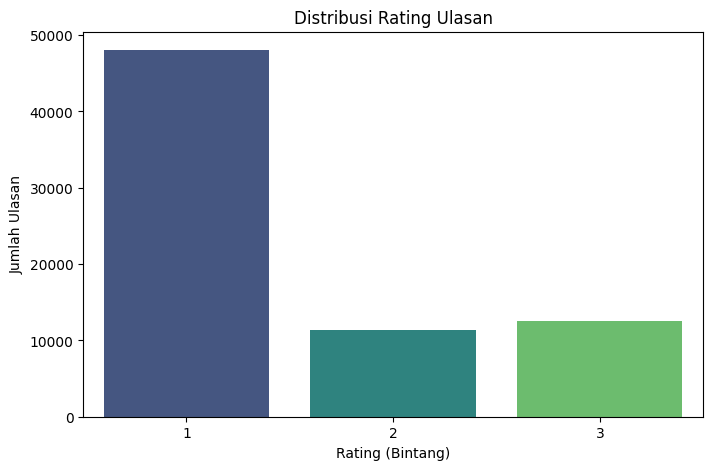

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='score', palette='viridis')
plt.title('Distribusi Rating Ulasan')
plt.xlabel('Rating (Bintang)')
plt.ylabel('Jumlah Ulasan')
plt.show()

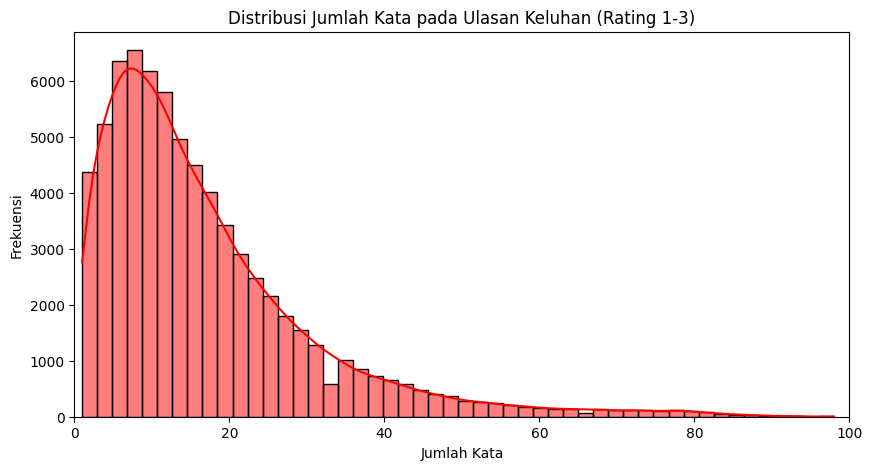

In [7]:
df['char_length'] = df['content'].astype(str).apply(len)
df['word_count'] = df['content'].astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df[df['score'] <= 3]['word_count'], bins=50, kde=True, color='red')
plt.title('Distribusi Jumlah Kata pada Ulasan Keluhan (Rating 1-3)')
plt.xlabel('Jumlah Kata')
plt.ylabel('Frekuensi')
plt.xlim(0, 100) # Batasi x-axis biar visualnya fokus
plt.show()

# Cleaning

In [8]:
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

In [9]:
df = df[['content', 'score', 'at', 'word_count']]
print(f"\nTotal data keluhan siap dibersihkan: {len(df)} baris")


Total data keluhan siap dibersihkan: 71882 baris


In [10]:
def clean_text_basic(text):
  text = str(text).lower()
  text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
  text = re.sub(r'[^a-z\s]', ' ', text)
  text = stopword_remover.remove(text)
  text = re.sub(r'\s+', ' ', text).strip()
  return text

df['content_cleaned'] = df['content'].apply(clean_text_basic)

In [11]:
# post cleaning checking
df['cleaned_word_count'] = df['content_cleaned'].apply(lambda x: len(str(x).split()))

# Buang ulasan yang sekarang jadi kurang dari 3 kata
df_final = df[df['cleaned_word_count'] >= 3].copy()

print(f"Total data final setelah dibersihkan: {len(df_final)} baris")
df_final.head()

Total data final setelah dibersihkan: 66521 baris


,content,score,at,word_count,content_cleaned,cleaned_word_count
2,"sekarang topup ewallet malah ribet, lol",1,2025-12-31 23:39:43,6,sekarang topup ewallet malah ribet lol,6
6,layanan gak bagus,1,2025-12-31 22:48:35,3,layanan gak bagus,3
10,knpa setiap buka aplikasi brimo sllu tampilanx...,1,2025-12-31 22:17:37,20,knpa buka aplikasi brimo sllu tampilanx putih ...,17
13,harus verifikasi lagi..di mna kondisi KTP suda...,1,2025-12-31 22:13:20,22,verifikasi mna kondisi ktp kusam kamera hp yg ...,15
17,Aplikasi eror mulu,1,2025-12-31 22:02:04,3,aplikasi eror mulu,3


In [12]:
df_final.isnull().sum()

content               0
score                 0
at                    0
word_count            0
content_cleaned       0
cleaned_word_count    0
dtype: int64